# CatBoost with Optuna Hyperparameter Tuning

This notebook trains a CatBoost model with:
- Custom data preprocessing
- Feature engineering
- Optuna hyperparameter optimization
- Model evaluation and predictions

CatBoost advantages:
- Handles categorical features natively
- Built-in feature importance
- Robust to overfitting

In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from catboost import CatBoostClassifier, Pool
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data

In [10]:
# Load training and test data
train_df = pd.read_csv('../dataset/train_dropped_column.csv')
test_df = pd.read_csv('../dataset/test_dropped_column.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTarget distribution:")
print(train_df['retention_status'].value_counts())
print(f"\nClass balance: {train_df['retention_status'].value_counts(normalize=True)}")

Training data shape: (59608, 23)
Test data shape: (14900, 22)

Target distribution:
retention_status
Stayed    31264
Left      28344
Name: count, dtype: int64

Class balance: retention_status
Stayed    0.524493
Left      0.475507
Name: proportion, dtype: float64


## 2. Data Preprocessing & Feature Engineering

In [11]:
def preprocess_and_engineer_features(df, is_train=True):
    """
    Preprocess data and engineer features for CatBoost
    CatBoost can handle categorical features directly, so we keep them as strings
    """
    df = df.copy()
    
    # Save founder_id for later
    founder_ids = df['founder_id'].copy()
    
    # Drop founder_id as it's not a feature
    df = df.drop('founder_id', axis=1)
    
    # Separate target if training data
    if is_train and 'retention_status' in df.columns:
        target = df['retention_status'].copy()
        df = df.drop('retention_status', axis=1)
    else:
        target = None
    
    # --- Feature Engineering ---
    
    # 1. Revenue-based features
    df['revenue_per_year'] = df['monthly_revenue_generated'] / (df['years_with_startup'] + 1)
    df['log_revenue'] = np.log1p(df['monthly_revenue_generated'])
    
    # 2. Age-related features
    df['age_when_joined'] = df['founder_age'] - df['years_with_startup']
    df['is_young_founder'] = (df['founder_age'] < 30).astype(int)
    df['is_senior_founder'] = (df['founder_age'] > 50).astype(int)
    df['age_group'] = pd.cut(df['founder_age'], bins=[0, 25, 35, 45, 55, 100], 
                              labels=['Very Young', 'Young', 'Middle', 'Senior', 'Very Senior'])
    
    # 3. Experience and tenure features
    df['experience_ratio'] = df['years_with_startup'] / (df['founder_age'] + 1)
    df['tenure_category'] = pd.cut(df['years_with_startup'], bins=[-1, 2, 5, 10, 20, 100],
                                   labels=['New', 'Short', 'Medium', 'Long', 'Very Long'])
    
    # 4. Work-life balance composite
    df['overtime_with_poor_balance'] = ((df['working_overtime'] == 'Yes') & 
                                         (df['work_life_balance_rating'].isin(['Poor', 'Fair']))).astype(int)
    df['good_balance_no_overtime'] = ((df['working_overtime'] == 'No') & 
                                       (df['work_life_balance_rating'].isin(['Good', 'Excellent']))).astype(int)
    
    # 5. Performance and satisfaction composite
    df['high_performer_satisfied'] = ((df['startup_performance_rating'] == 'High') & 
                                       (df['venture_satisfaction'].isin(['High', 'Very High']))).astype(int)
    df['low_performer_unsatisfied'] = ((df['startup_performance_rating'].isin(['Low', 'Below Average'])) & 
                                        (df['venture_satisfaction'] == 'Low')).astype(int)
    
    # 6. Leadership and funding features
    df['has_led_funding'] = (df['funding_rounds_led'] > 0).astype(int)
    df['funding_experience_score'] = df['funding_rounds_led'] * df['years_with_startup']
    df['avg_funding_per_year'] = df['funding_rounds_led'] / (df['years_with_startup'] + 1)
    
    # 7. Location features
    df['distance_category'] = pd.cut(df['distance_from_investor_hub'], 
                                     bins=[-1, 20, 40, 60, 100],
                                     labels=['Very Close', 'Close', 'Moderate', 'Far'])
    df['near_investor_hub'] = (df['distance_from_investor_hub'] < 30).astype(int)
    
    # 8. Family and personal features
    df['has_dependents'] = (df['num_dependents'] > 0).astype(int)
    df['family_size'] = df['num_dependents'] + 1
    df['dependents_category'] = pd.cut(df['num_dependents'], bins=[-1, 0, 2, 4, 10],
                                       labels=['None', 'Few', 'Several', 'Many'])
    
    # 9. Role and industry interaction
    df['tech_finance_role'] = df['founder_role'].isin(['Technology', 'Finance']).astype(int)
    
    # 10. Education and performance
    df['high_education'] = df['education_background'].isin(["Master's Degree", 'PhD']).astype(int)
    
    # 11. Team and company features
    df['large_team'] = (df['team_size_category'] == 'Large').astype(int)
    df['excellent_reputation'] = (df['startup_reputation'] == 'Excellent').astype(int)
    df['high_visibility'] = df['founder_visibility'].isin(['High', 'Very High']).astype(int)
    
    # 12. Innovation and leadership combination
    df['innovation_leader'] = ((df['leadership_scope'] == 'Yes') & 
                                (df['innovation_support'] == 'Yes')).astype(int)
    df['remote_innovator'] = ((df['remote_operations'] == 'Yes') & 
                              (df['innovation_support'] == 'Yes')).astype(int)
    
    # 13. Engagement score
    satisfaction_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
    performance_map = {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4}
    balance_map = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
    
    df['satisfaction_score'] = df['venture_satisfaction'].map(satisfaction_map)
    df['performance_score'] = df['startup_performance_rating'].map(performance_map)
    df['balance_score'] = df['work_life_balance_rating'].map(balance_map)
    df['engagement_score'] = (df['satisfaction_score'] + df['performance_score'] + df['balance_score']) / 3
    
    # 14. Revenue to distance ratio
    df['revenue_distance_ratio'] = df['monthly_revenue_generated'] / (df['distance_from_investor_hub'] + 1)
    
    # Handle missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    # Handle NaN values in categorical columns (CatBoost requires string or int, not NaN)
    # Convert category columns to object first to avoid categorical issues
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        if df[col].dtype.name == 'category':
            df[col] = df[col].astype(str)
        df[col] = df[col].fillna('Unknown')
    
    return df, target, founder_ids

# Preprocess data
X_train, y_train, train_ids = preprocess_and_engineer_features(train_df, is_train=True)
X_test, _, test_ids = preprocess_and_engineer_features(test_df, is_train=False)

print(f"\nPreprocessed training features shape: {X_train.shape}")
print(f"Preprocessed test features shape: {X_test.shape}")


Preprocessed training features shape: (59608, 53)
Preprocessed test features shape: (14900, 53)


In [12]:
# Identify categorical features for CatBoost
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)

# Align test set columns with training set
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    if col in categorical_features:
        X_test[col] = 'Unknown'
    else:
        X_test[col] = 0

extra_cols = set(X_test.columns) - set(X_train.columns)
X_test = X_test.drop(columns=list(extra_cols))

# Ensure same column order
X_test = X_test[X_train.columns]

print(f"\nAligned test features shape: {X_test.shape}")


Categorical features (19):
['founder_gender', 'founder_role', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'working_overtime', 'education_background', 'personal_status', 'startup_stage', 'team_size_category', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility', 'age_group', 'tenure_category', 'distance_category', 'dependents_category']

Aligned test features shape: (14900, 53)


## 3. Train-Validation Split

In [13]:
# Split data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")

Training set: (47686, 53)
Validation set: (11922, 53)


## 4. Optuna Hyperparameter Tuning

In [14]:
def objective(trial):
    """
    Objective function for Optuna optimization
    """
    # Suggest hyperparameters
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'random_state': RANDOM_STATE,
        'verbose': 0,
        'cat_features': categorical_features,
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['Balanced', None])
    }
    
    # Train model with cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train_split, y_train_split):
        X_fold_train, X_fold_val = X_train_split.iloc[train_idx], X_train_split.iloc[val_idx]
        y_fold_train, y_fold_val = y_train_split.iloc[train_idx], y_train_split.iloc[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(X_fold_train, y_fold_train, eval_set=(X_fold_val, y_fold_val), 
                 early_stopping_rounds=50, verbose=False)
        
        y_pred = model.predict(X_fold_val)
        score = accuracy_score(y_fold_val, y_pred)
        scores.append(score)
    
    return np.mean(scores)

# Create Optuna study
print("Starting Optuna hyperparameter optimization...\n")
print("This may take several minutes...\n")
study = optuna.create_study(direction='maximize', study_name='catboost_optimization')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n{'='*50}")
print("Optimization Complete!")
print(f"{'='*50}")
print(f"Best accuracy: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-26 21:09:19,353] A new study created in memory with name: catboost_optimization


Starting Optuna hyperparameter optimization...

This may take several minutes...



Best trial: 0. Best value: 0.75043:   3%|▎         | 1/30 [01:41<48:54, 101.19s/it]

[I 2025-11-26 21:11:00,553] Trial 0 finished with value: 0.750429851811758 and parameters: {'iterations': 933, 'learning_rate': 0.010502484276629033, 'depth': 9, 'l2_leaf_reg': 4.4449770566120375, 'random_strength': 7.780921831320616, 'bagging_temperature': 0.7946965451745241, 'border_count': 97, 'grow_policy': 'Lossguide', 'min_data_in_leaf': 96, 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.750429851811758.


Best trial: 1. Best value: 0.752212:   7%|▋         | 2/30 [03:38<51:36, 110.59s/it]

...

[I 2025-11-26 21:30:34,317] Trial 27 finished with value: 0.7534495849318147 and parameters: {'iterations': 964, 'learning_rate': 0.10009683884066081, 'depth': 5, 'l2_leaf_reg': 2.9454062012173474, 'random_strength': 2.61165373139115, 'bagging_temperature': 0.5772852288074656, 'border_count': 73, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 10, 'auto_class_weights': 'Balanced'}. Best is trial 4 with value: 0.7549594541303626.


Best trial: 4. Best value: 0.754959:  97%|█████████▋| 29/30 [21:56<00:42, 42.36s/it]

[I 2025-11-26 21:31:15,502] Trial 28 finished with value: 0.7531769717486827 and parameters: {'iterations': 1273, 'learning_rate': 0.04671975393692732, 'depth': 6, 'l2_leaf_reg': 1.0869248315804692, 'random_strength': 3.908035137200453, 'bagging_temperature': 0.9114901996576291, 'border_count': 56, 'grow_policy': 'Lossguide', 'min_data_in_leaf': 21, 'auto_class_weights': None}. Best is trial 4 with value: 0.7549594541303626.


Best trial: 4. Best value: 0.754959: 100%|██████████| 30/30 [22:23<00:00, 44.79s/it]

[I 2025-11-26 21:31:42,974] Trial 29 finished with value: 0.7515831699166107 and parameters: {'iterations': 821, 'learning_rate': 0.07320204080191133, 'depth': 8, 'l2_leaf_reg': 4.903654380314576, 'random_strength': 8.008854788346312, 'bagging_temperature': 0.7589940675110549, 'border_count': 90, 'grow_policy': 'Depthwise', 'min_data_in_leaf': 56, 'auto_class_weights': 'Balanced'}. Best is trial 4 with value: 0.7549594541303626.

Optimization Complete!
Best accuracy: 0.7550

Best hyperparameters:
  iterations: 1001
  learning_rate: 0.10132827434713908
  depth: 4
  l2_leaf_reg: 3.474656421326844
  random_strength: 1.9068314292508226
  bagging_temperature: 0.8784091254337011
  border_count: 176
  grow_policy: SymmetricTree
  min_data_in_leaf: 9
  auto_class_weights: Balanced


## 5. Train Final Model with Best Parameters

In [15]:
# Train final model with best parameters
best_params = study.best_params.copy()
best_params['random_state'] = RANDOM_STATE
best_params['cat_features'] = categorical_features
best_params['verbose'] = 100

final_model = CatBoostClassifier(**best_params)
final_model.fit(
    X_train_split, y_train_split,
    eval_set=(X_val_split, y_val_split),
    early_stopping_rounds=100,
    verbose=100
)

print("\nFinal model trained successfully!")

0:	learn: 0.6635581	test: 0.6632199	best: 0.6632199 (0)	total: 26.2ms	remaining: 26.2s
100:	learn: 0.4814975	test: 0.4855826	best: 0.4855826 (100)	total: 3.98s	remaining: 35.5s
100:	learn: 0.4814975	test: 0.4855826	best: 0.4855826 (100)	total: 3.98s	remaining: 35.5s
200:	learn: 0.4726736	test: 0.4815691	best: 0.4815691 (200)	total: 7.96s	remaining: 31.7s
200:	learn: 0.4726736	test: 0.4815691	best: 0.4815691 (200)	total: 7.96s	remaining: 31.7s
300:	learn: 0.4677389	test: 0.4808406	best: 0.4807130 (258)	total: 11.9s	remaining: 27.8s
300:	learn: 0.4677389	test: 0.4808406	best: 0.4807130 (258)	total: 11.9s	remaining: 27.8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4807129733
bestIteration = 258

Shrink model to first 259 iterations.

Final model trained successfully!
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4807129733
bestIteration = 258

Shrink model to first 259 iterations.

Final model trained successfully!


## 6. Model Evaluation

In [17]:
# Make predictions on validation set
y_val_pred = final_model.predict(X_val_split)
y_val_pred_proba = final_model.predict_proba(X_val_split)

# Calculate metrics
val_accuracy = accuracy_score(y_val_split, y_val_pred)
# Encode target for ROC AUC calculation (Left=0, Stayed=1)
y_val_split_encoded = y_val_split.map({'Left': 0, 'Stayed': 1})
val_roc_auc = roc_auc_score(y_val_split_encoded, y_val_pred_proba[:, 1])

print(f"{'='*50}")
print("Validation Set Performance")
print(f"{'='*50}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"ROC AUC Score: {val_roc_auc:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_val_split, y_val_pred))

Validation Set Performance
Accuracy: 0.7531
ROC AUC Score: 0.8444

Classification Report:
              precision    recall  f1-score   support

        Left       0.73      0.76      0.74      5669
      Stayed       0.77      0.75      0.76      6253

    accuracy                           0.75     11922
   macro avg       0.75      0.75      0.75     11922
weighted avg       0.75      0.75      0.75     11922



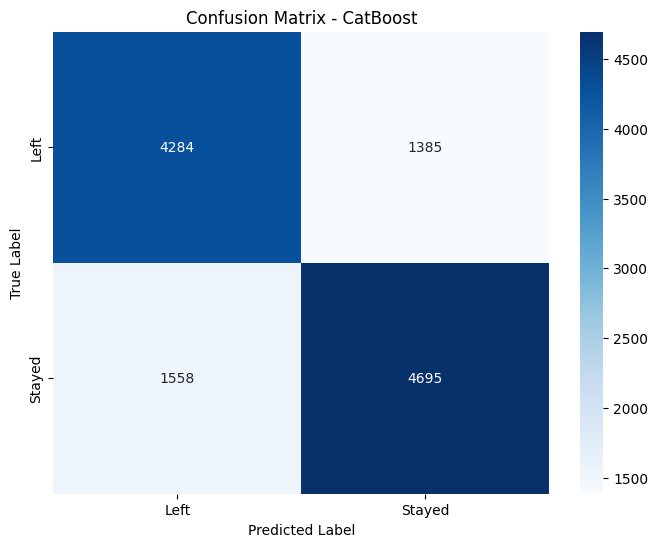

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_val_split, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Left', 'Stayed'], yticklabels=['Left', 'Stayed'])
plt.title('Confusion Matrix - CatBoost')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

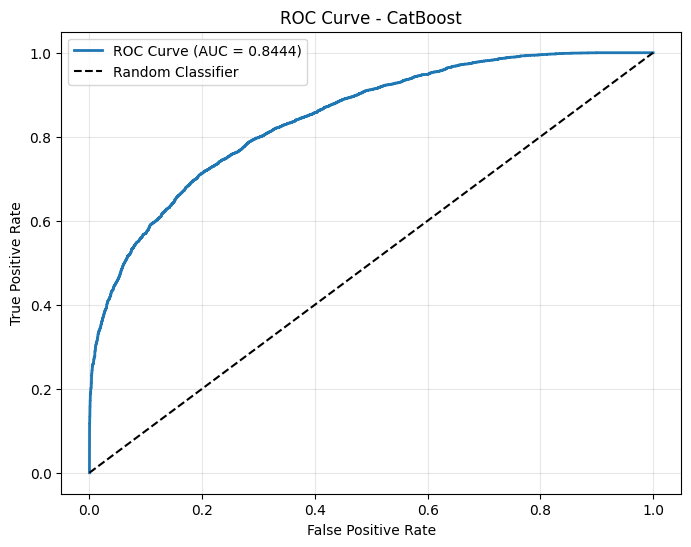

In [20]:
# ROC Curve
# Encode target for ROC curve calculation
y_val_split_encoded = y_val_split.map({'Left': 0, 'Stayed': 1})
fpr, tpr, thresholds = roc_curve(y_val_split_encoded, y_val_pred_proba[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {val_roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CatBoost')
plt.legend()

plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Visualize optimization history
try:
    fig = plot_optimization_history(study)
    fig.show()
    
    # Visualize parameter importances
    fig = plot_param_importances(study)
    fig.show()
except ImportError:
    print("Plotly not installed. Skipping visualizations.")
    print("To install: pip install plotly kaleido")

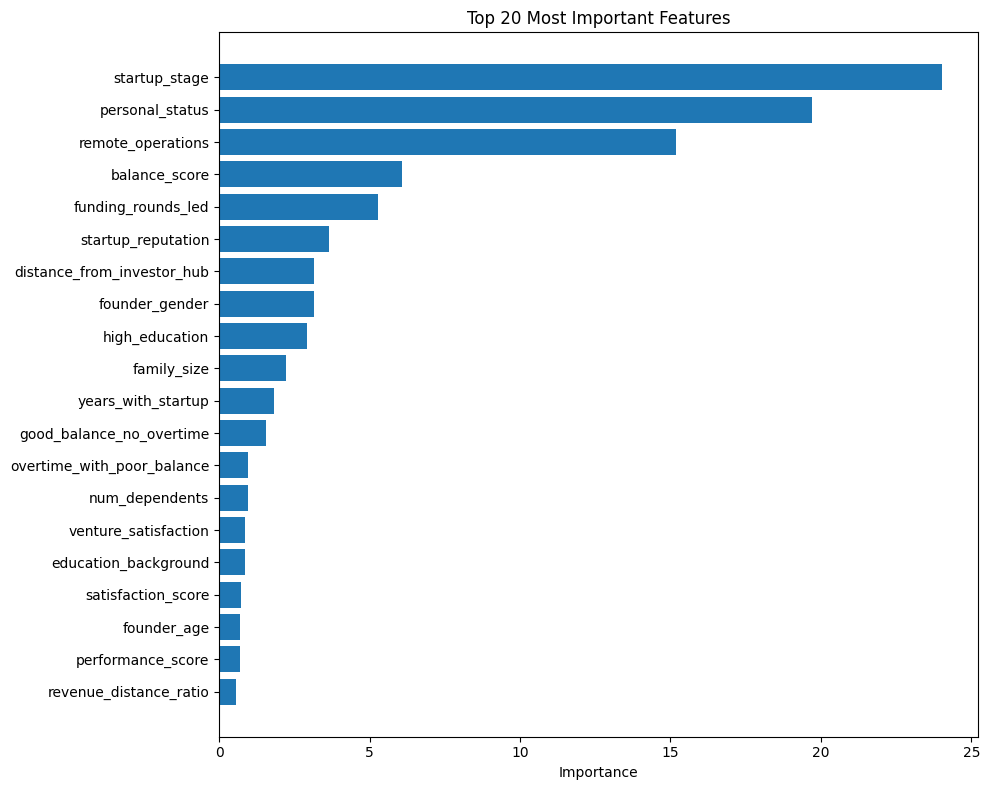


Top 20 Most Important Features:
                   feature  importance
             startup_stage   24.032012
           personal_status   19.719086
         remote_operations   15.185228
             balance_score    6.062727
        funding_rounds_led    5.267501
        startup_reputation    3.641397
distance_from_investor_hub    3.158528
            founder_gender    3.140862
            high_education    2.925161
               family_size    2.237424
        years_with_startup    1.835737
  good_balance_no_overtime    1.570239
overtime_with_poor_balance    0.969856
            num_dependents    0.949365
      venture_satisfaction    0.876020
      education_background    0.860665
        satisfaction_score    0.732903
               founder_age    0.705086
         performance_score    0.678576
    revenue_distance_ratio    0.571027


In [22]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Features:")
print(feature_importance.to_string(index=False))

## 7. Retrain on Full Training Data

In [23]:
# Retrain on full training data for final predictions
print("Retraining model on full training data...\n")
final_model_full = CatBoostClassifier(**best_params)
final_model_full.fit(X_train, y_train, verbose=100)
print("\nModel retrained successfully!")

Retraining model on full training data...

0:	learn: 0.6634241	total: 42.8ms	remaining: 42.8s
0:	learn: 0.6634241	total: 42.8ms	remaining: 42.8s
100:	learn: 0.4819750	total: 3.25s	remaining: 29s
100:	learn: 0.4819750	total: 3.25s	remaining: 29s
200:	learn: 0.4740132	total: 7.93s	remaining: 31.5s
200:	learn: 0.4740132	total: 7.93s	remaining: 31.5s
300:	learn: 0.4697548	total: 12.6s	remaining: 29.3s
300:	learn: 0.4697548	total: 12.6s	remaining: 29.3s
400:	learn: 0.4667492	total: 17.9s	remaining: 26.8s
400:	learn: 0.4667492	total: 17.9s	remaining: 26.8s
500:	learn: 0.4637133	total: 22.7s	remaining: 22.7s
500:	learn: 0.4637133	total: 22.7s	remaining: 22.7s
600:	learn: 0.4612373	total: 27.6s	remaining: 18.3s
600:	learn: 0.4612373	total: 27.6s	remaining: 18.3s
700:	learn: 0.4586972	total: 32.4s	remaining: 13.9s
700:	learn: 0.4586972	total: 32.4s	remaining: 13.9s
800:	learn: 0.4563273	total: 37.3s	remaining: 9.3s
800:	learn: 0.4563273	total: 37.3s	remaining: 9.3s
900:	learn: 0.4537739	total: 

## 8. Generate Test Predictions

In [24]:
# Make predictions on test set
y_test_pred = final_model_full.predict(X_test)
y_test_pred_proba = final_model_full.predict_proba(X_test)

print(f"Test predictions generated!")
print(f"\nPrediction distribution:")
print(pd.Series(y_test_pred.flatten()).value_counts())

Test predictions generated!

Prediction distribution:
Stayed    7515
Left      7385
Name: count, dtype: int64


## 9. Save Predictions

In [25]:
# Create submission file with probabilities
submission_probs = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred.flatten(),
    'probability_Left': y_test_pred_proba[:, 0],
    'probability_Stayed': y_test_pred_proba[:, 1]
})

submission_probs.to_csv('catboost_predictions_with_probs.csv', index=False)
print("Predictions with probabilities saved to 'catboost_predictions_with_probs.csv'")

# Create standard submission file
submission = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred.flatten()
})

submission.to_csv('submission_catboost.csv', index=False)
print("Submission file saved to 'submission_catboost.csv'")

print("\nFirst few predictions:")
print(submission.head(10))

Predictions with probabilities saved to 'catboost_predictions_with_probs.csv'
Submission file saved to 'submission_catboost.csv'

First few predictions:
   founder_id retention_status
0       52685           Stayed
1       30585             Left
2       54656           Stayed
3       33442             Left
4       15667           Stayed
5        3496           Stayed
6       46775             Left
7       72645             Left
8        4941             Left
9       65181             Left


## 10. Model Summary

In [26]:
# Save model
final_model_full.save_model('catboost_model.cbm')
print("Model saved to 'catboost_model.cbm'")

# Save model summary
summary = f"""
{'='*60}
CATBOOST MODEL SUMMARY
{'='*60}

Dataset Information:
- Training samples: {len(X_train)}
- Test samples: {len(X_test)}
- Number of features: {X_train.shape[1]}
- Categorical features: {len(categorical_features)}

Best Hyperparameters:
{chr(10).join(f'- {k}: {v}' for k, v in best_params.items() if k != 'cat_features')}

Validation Performance:
- Accuracy: {val_accuracy:.4f}
- ROC AUC: {val_roc_auc:.4f}
- Best Iteration: {final_model.best_iteration_}

Feature Engineering Applied:
- Revenue-based features (per year, log transformed)
- Age-related features (groups, young/senior indicators)
- Experience and tenure features (ratios, categories)
- Work-life balance composites
- Performance and satisfaction interactions
- Leadership and funding metrics
- Location features (distance categories)
- Family and personal features
- Role and industry interactions
- Education level indicators
- Team and company features
- Innovation and leadership combinations
- Engagement score composite
- Revenue to distance ratio

Top 5 Most Important Features:
{chr(10).join(f'{i+1}. {row["feature"]}: {row["importance"]:.4f}' for i, row in feature_importance.head(5).iterrows())}

Preprocessing Steps:
1. Handled missing values with median imputation
2. Kept categorical variables for CatBoost native handling
3. Created interaction features
4. Binned continuous variables into categories

Optuna Optimization:
- Number of trials: 30
- Cross-validation folds: 3
- Best CV score: {study.best_value:.4f}

Output Files:
- catboost_predictions_with_probs.csv
- submission_catboost.csv
- catboost_model.cbm
{'='*60}
"""

print(summary)

with open('catboost_summary.txt', 'w') as f:
    f.write(summary)

print("\nModel summary saved to 'catboost_summary.txt'")

Model saved to 'catboost_model.cbm'

CATBOOST MODEL SUMMARY

Dataset Information:
- Training samples: 59608
- Test samples: 14900
- Number of features: 53
- Categorical features: 19

Best Hyperparameters:
- iterations: 1001
- learning_rate: 0.10132827434713908
- depth: 4
- l2_leaf_reg: 3.474656421326844
- random_strength: 1.9068314292508226
- bagging_temperature: 0.8784091254337011
- border_count: 176
- grow_policy: SymmetricTree
- min_data_in_leaf: 9
- auto_class_weights: Balanced
- random_state: 42
- verbose: 100

Validation Performance:
- Accuracy: 0.7531
- ROC AUC: 0.8444
- Best Iteration: 258

Feature Engineering Applied:
- Revenue-based features (per year, log transformed)
- Age-related features (groups, young/senior indicators)
- Experience and tenure features (ratios, categories)
- Work-life balance composites
- Performance and satisfaction interactions
- Leadership and funding metrics
- Location features (distance categories)
- Family and personal features
- Role and industry 